# 02 — The 2-bit front end and the CAM key

In notebook 01 we had complex floating-point samples. Real hardware does not. This notebook
turns `r[n]` into **bits** and asks what that costs.

By the end you should be able to answer:

1. What does the 2-bit ADC do, and why is its threshold at 1.0$\sigma$?
2. What is the "1.96 dB limiting loss", and why is it *not* the CAM's fault?
3. How does a sample become a CAM key — and what is the thermometer code buying?
4. Why is Hamming distance a *correlation*, and what exactly is missing from it?
5. Why is $\theta_0$ **free** and Doppler **expensive**? (the placement principle)

Modules used: [`sim/gps/quantize.py`](../sim/gps/quantize.py).

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from sim.gps import prn, channel, codebook, quantize

plt.rcParams.update({"figure.figsize": (9, 3), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})

FS, T = 2.046e6, 1e-3
NS = int(round(FS * T))

---
## 1. Why quantize at all?

Two reasons, and only one of them is about the CAM.

1. **Every GNSS receiver does this anyway.** 1–2 bit front ends are standard practice: the
   signal is far below the noise, so the ADC is really digitizing *noise*, and extra bits buy
   very little. This is why the loss we measure in section 3 is not chargeable to our design.
2. **A CAM compares bits.** There is no multiplier in the array, no accumulator, no squarer.
   Whatever the receiver is going to do, it must be expressible as *bit comparisons*.

The design question this notebook sets up: given that everything is bits, **which** bits?

---
## 2. The 2-bit ADC

[`quantize.adc_2bit`](../sim/gps/quantize.py) maps a real rail to one of four levels
$\{-3,-1,+1,+3\}$ (returned as indices 0..3) using three thresholds: $-t$, $0$, $+t$, where
$t$ is quoted in units of the noise $\sigma$.

Because notebook 01's convention fixes $\sigma = 1$ and scales the *signal*, this threshold
stays put across the whole C/N0 sweep — exactly as a settled AGC would hold it.

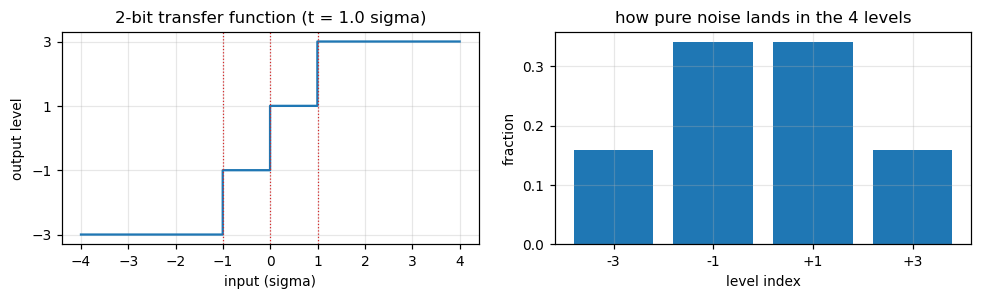

sanity: [0 0 1 2 3 3] (expect 0 0 1 2 3 3)


In [2]:
x = np.linspace(-4, 4, 801)
lv = quantize.adc_2bit(x, sigma=1.0, threshold=1.0)

fig, axes = plt.subplots(1, 2, figsize=(9, 2.8))
axes[0].step(x, quantize.LEVELS[lv], where="mid")
for t in (-1, 0, 1):
    axes[0].axvline(t, color="C3", ls=":", lw=0.8)
axes[0].set(xlabel="input (sigma)", ylabel="output level",
            title="2-bit transfer function (t = 1.0 sigma)", yticks=[-3, -1, 1, 3])

noise = np.random.default_rng(0).normal(0, 1, 200_000)
axes[1].hist(quantize.adc_2bit(noise, 1.0, 1.0), bins=[-.5, .5, 1.5, 2.5, 3.5],
             rwidth=0.8, density=True)
axes[1].set(xlabel="level index", ylabel="fraction", title="how pure noise lands in the 4 levels",
            xticks=[0, 1, 2, 3], xticklabels=["-3", "-1", "+1", "+3"])
plt.tight_layout(); plt.show()

print("sanity:", quantize.adc_2bit(np.array([-5., -1.5, -0.5, 0.5, 1.5, 5.]), 1.0), "(expect 0 0 1 2 3 3)")

### Why $t = 1.0\sigma$? Let's not take it on faith — measure it.

We sweep the threshold and measure the *output SNR of the correlator*
$\;|\mathbb{E}[z]|^2 / \mathrm{Var}(z)\,$, relative to a full-precision correlator on the same
samples. The optimum is where the curve peaks.

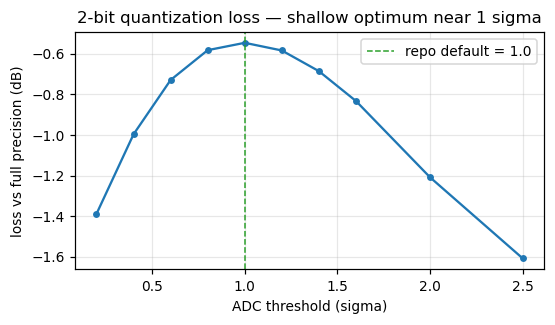

best threshold 1.0 sigma at -0.55 dB loss


In [3]:
rep = channel.replica(1, 0.0, FS, NS, theta=0.0)          # matched replica, theta0 = 0

def corr_out(kind, cn0, trials, thr=1.0, seed=0):
    # Correlator outputs z over `trials` independent noise realizations.
    rng = np.random.default_rng(seed)
    s = channel.amplitude_for_cn0(cn0, FS) * rep
    r = s[None, :] + rng.normal(0, 1, (trials, NS)) + 1j * rng.normal(0, 1, (trials, NS))
    if kind == "full":
        x = r
    elif kind == "sign":
        x = np.sign(r.real) + 1j * np.sign(r.imag)
    else:                                                  # the true 2-bit correlator
        x = (quantize.LEVELS[quantize.adc_2bit(r.real, 1.0, thr)]
             + 1j * quantize.LEVELS[quantize.adc_2bit(r.imag, 1.0, thr)])
    return x @ np.conj(rep)

snr_of = lambda z: abs(z.mean()) ** 2 / z.var()

TRIALS = 20_000
ref = snr_of(corr_out("full", 38, TRIALS, seed=2))
thrs = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 2.0, 2.5])
loss = np.array([10 * np.log10(snr_of(corr_out("2bit", 38, TRIALS, thr=t, seed=2)) / ref) for t in thrs])

fig, ax = plt.subplots(figsize=(5.5, 2.8))
ax.plot(thrs, loss, "o-", ms=3.5)
ax.axvline(quantize.DEFAULT_THRESHOLD, color="C2", ls="--", lw=1, label="repo default = 1.0")
ax.set(xlabel="ADC threshold (sigma)", ylabel="loss vs full precision (dB)",
       title="2-bit quantization loss — shallow optimum near 1 sigma")
ax.legend(); plt.show()

print(f"best threshold {thrs[loss.argmax()]:.1f} sigma at {loss.max():.2f} dB loss")

The optimum sits at **1.0$\sigma$** and the curve is *shallow* — anywhere in 0.8–1.2 costs
under 0.6 dB. That shallowness is good news for hardware: the AGC does not have to be
precise. It also means a 2-bit front end costs only about **half a dB**, which is worth
holding on to for the next section.

---
## 3. The 1.96 dB limiting loss

Now throw away the magnitude entirely and keep only the **sign** of each rail — 1 bit per
rail. Theory says a hard limiter costs a factor of $2/\pi$ in output SNR:

$$ 10\log_{10}(2/\pi) = -1.96\ \text{dB} $$

This is the single most important number for reading this repo's results honestly, because
it is the loss the CAM does **not** get blamed for — any 1-bit front end pays it, CAM or not.

In [4]:
for cn0 in [38, 45]:
    f = snr_of(corr_out("full", cn0, TRIALS, seed=1))
    s = snr_of(corr_out("sign", cn0, TRIALS, seed=1))
    print(f"C/N0 = {cn0} dB-Hz | full precision {10*np.log10(f):5.2f} dB | "
          f"sign only {10*np.log10(s):5.2f} dB | loss {10*np.log10(s/f):+.3f} dB")
print(f"\ntheory: 10*log10(2/pi) = {10*np.log10(2/np.pi):+.3f} dB")

C/N0 = 38 dB-Hz | full precision  7.93 dB | sign only  5.96 dB | loss -1.965 dB
C/N0 = 45 dB-Hz | full precision 14.95 dB | sign only 13.00 dB | loss -1.955 dB

theory: 10*log10(2/pi) = -1.961 dB


Measured $-1.965$ dB against a predicted $-1.961$ dB. When a number lands this cleanly on
theory, the plumbing underneath it is almost certainly right — this is the same logic the
repo's `tests/gps/test_margin.py` uses as a gate.

> **The accounting that follows from this**, and which notebook 08 will complete:
>
> | step | cost | whose fault? |
> |---|---|---|
> | full precision → 2-bit | ~0.5 dB | the front end (§2) |
> | full precision → 1-bit sign | 1.96 dB | the front end (§3) |
> | 1-bit sign → **CAM** | **+1.9 dB** | *ours* — the boolean readout |
>
> Without this decomposition you would charge the CAM ~3.9 dB and conclude the architecture
> is much worse than it is.

---
## 4. From levels to a CAM key

A key is a flat bit vector. Two mappings are offered, and they differ in what Hamming
distance *means*.

| mapping | bits/rail | Hamming distance means |
|---|---|---|
| `sign` | 1 | sign–sign correlation (a hard-decision correlator) |
| `thermometer` | 3 | **L1 distance between ADC levels** — a magnitude-weighted, soft correlation |

The thermometer code writes level $\ell$ as $[\ell > 0, \ell > 1, \ell > 2]$, i.e. `000`,
`100`, `110`, `111`. Its point is a *metric* property, which we verify rather than assume.

In [5]:
bits = quantize.levels_to_thermo_bits(np.arange(4))
for i, lvl in enumerate(quantize.LEVELS):
    print(f"level {lvl:+.0f} (index {i}) -> thermometer {bits[i]}")

print("\nHamming distance between thermometer words vs |level difference|:")
ok = True
for a in range(4):
    row = []
    for b in range(4):
        h = int((bits[a] != bits[b]).sum())
        ok &= (h == abs(a - b))
        row.append(h)
    print("  ", row)
print(f"\nHamming == L1 distance in levels for every pair: {ok}")

level -3 (index 0) -> thermometer [0 0 0]
level -1 (index 1) -> thermometer [1 0 0]
level +1 (index 2) -> thermometer [1 1 0]
level +3 (index 3) -> thermometer [1 1 1]

Hamming distance between thermometer words vs |level difference|:
   [0, 1, 2, 3]
   [1, 0, 1, 2]
   [2, 1, 0, 1]
   [3, 2, 1, 0]

Hamming == L1 distance in levels for every pair: True


### Key layout, and a hardware subtlety worth pausing on

`make_key` interleaves the rails **sample-major**: `[I0 Q0 I1 Q1 ...]`, each rail contributing
`bits_per_rail` bits. So the sign key for a 1 ms dwell is $2046 \times 2 = 4092$ bits.

Now the subtlety. Codebook **rows** are noiseless replicas taken to *full scale*, so a
thermometer row only ever holds `000` or `111` — one bit of real information. The thermometer
mapping therefore widens the **match line** (3 comparison cells per rail) but *not* the
**stored state** (still 1 bit per rail). Area and memory are not the same axis here.

In [6]:
print(f"sign        key width: {quantize.key_width(NS,'sign'):6d} bits")
print(f"thermometer key width: {quantize.key_width(NS,'thermometer'):6d} bits  (3x)")
print(f"stored state per row : {quantize.row_state_bits(NS):6d} bits  (SAME for both mappings)")
print()
n_fd = len(codebook.doppler_grid(10e3, T))
print(f"full dictionary, 32 PRN x {n_fd} Doppler rows: "
      f"{32 * n_fd * quantize.row_state_bits(NS) / 1e6:.2f} Mbit")
print("  ^ this is the 5.37 Mbit that appears in figures/gps_segmentation.md for S=1")

sign        key width:   4092 bits
thermometer key width:  12276 bits  (3x)
stored state per row :   4092 bits  (SAME for both mappings)

full dictionary, 32 PRN x 41 Doppler rows: 5.37 Mbit
  ^ this is the 5.37 Mbit that appears in figures/gps_segmentation.md for S=1


---
## 5. Hamming distance **is** a correlation

Map a bit $b$ to $\pm1$ via $a = 1-2b$. Then for a key and a row of width $W$:

$$ \sum_i a_i b_i \;=\; W - 2\,\mathrm{HD} $$

So "small Hamming distance" and "large correlation" are the *same statement*. The CAM's
approximate-match operation is not an approximation of a correlator — it is one.

In [7]:
cb = codebook.build_codebook(prns=[1], f_max=0.0, t_coh=T, fs=FS, mapping="sign")
row = cb.rows[0]
r = channel.generate(1, 45, 0.0, FS, NS, theta0=codebook.ROW_THETA,
                     code_phase_chips=0.0, rng=np.random.default_rng(0)).samples
key = quantize.quantize_to_key(r, 1.0, "sign").astype(bool)

hd = int((key != row).sum())
a, b = 1 - 2 * key.astype(int), 1 - 2 * row.astype(int)
print(f"W = {cb.W}")
print(f"Hamming distance      HD = {hd}")
print(f"W - 2*HD                 = {cb.W - 2*hd}")
print(f"correlation  dot(a, b)   = {a @ b}    <- identical")
print()
print(f"chance level is HD = W/2 = {cb.W//2}. We are at {hd}, i.e. {(0.5 - hd/cb.W)*100:.1f}% below chance.")

W = 4092
Hamming distance      HD = 1875
W - 2*HD                 = 342
correlation  dot(a, b)   = 342    <- identical

chance level is HD = W/2 = 2046. We are at 1875, i.e. 4.2% below chance.


> **Read that last number carefully.** The correct row sits only ~4% below chance here, and
> at the 38 dB-Hz operating point it is **2.2%**. In the BLE study the equivalent figure is
> ~27% below chance. GNSS spreads its processing gain thinly across a very wide word, so the
> sense amplifier must resolve a *tiny* fraction of the match line's own width. That is the
> central hardware question of the whole project, and notebook 06 quantifies it.

### So what is actually missing?

Not the multiply — we just showed the array does that. What is missing is the **magnitude**.
A conventional receiver computes $|z|^2$ to remove the unknown carrier phase $\theta_0$. A
CAM has no squarer. The next section is how this architecture gets around that.

---
## 6. The free 90° rotation

Multiplying a complex sample by $j$ is $(I, Q) \rightarrow (-Q, I)$. On quantized rails that
is a **rail swap plus an inversion** — pure wiring. No multiplier, no re-quantization, and
crucially **no loss**, because it is exact rather than approximate.

`quantize.rotate_key` performs it on the bit vector directly. Let's check it is genuinely
exact: rotating the *key* must equal quantizing the *rotated waveform*, bit for bit.

In [8]:
k = quantize.quantize_to_key(r, 1.0, "sign")
for mapping in ["sign", "thermometer"]:
    km = quantize.quantize_to_key(r, 1.0, mapping)
    for q in range(4):
        direct = quantize.quantize_to_key(r * np.exp(1j * np.pi / 2 * q), 1.0, mapping)
        assert np.array_equal(direct, quantize.rotate_key(km, q, mapping))
    print(f"{mapping:12s}: rotate_key(key, q) == quantize(r * e^(j*90*q)) for all q  -> EXACT")

sign        : rotate_key(key, q) == quantize(r * e^(j*90*q)) for all q  -> EXACT
thermometer : rotate_key(key, q) == quantize(r * e^(j*90*q)) for all q  -> EXACT


### What the sweep buys: never blind, at most 3 dB of ripple

The rows are stored at $\theta = 45°$. Sweeping the four free rotations and keeping the best
means the residual phase error is at most $45°$, costing $\cos 45° = 0.707$.

Watch what happens *without* the sweep. We measure the detection **margin** — how far the
aligned-cell Hamming distance sits below the wrong-cell distribution, in units of its
standard deviation — as the true $\theta_0$ walks around the circle.

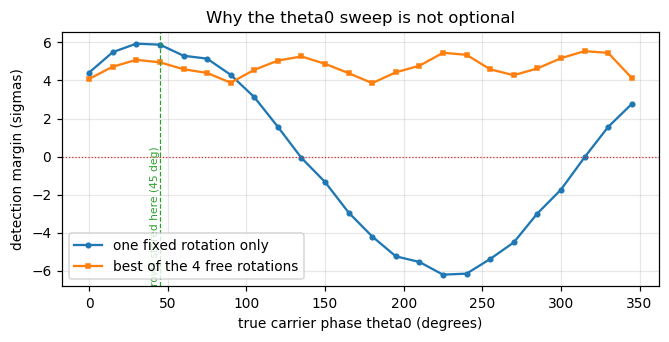

one rotation only : margin ranges -6.20 .. +5.93  <- goes NEGATIVE (anti-matched)
best of four      : margin ranges +3.86 .. +5.54  <- never blind

ripple = 0.697 of peak;  cos(45 deg) = 0.707


In [9]:
def margins_vs_theta(thetas, trials=250, cn0=45, seed=7):
    # Detection margin at each theta0: quadrant 0 alone vs the best of all 4.
    rng = np.random.default_rng(seed)
    rep1 = channel.replica(1, 0.0, FS, NS, code_phase_chips=0.0, theta=0.0)   # aligned
    rep0 = channel.replica(1, 0.0, FS, NS, code_phase_chips=511.0, theta=0.0)  # wrong phase
    A = channel.amplitude_for_cn0(cn0, FS)
    m_q0, m_best = [], []
    for th in thetas:
        def dists(rep):   # (trials, 4) Hamming distances, one column per rotation
            w = rng.normal(0, 1, (trials, NS)) + 1j * rng.normal(0, 1, (trials, NS))
            keys = quantize.quantize_to_key(A * np.exp(1j * th) * rep[None, :] + w, 1.0, "sign")
            return np.stack([(quantize.rotate_key(keys, q, "sign").astype(bool) != row).sum(1)
                             for q in range(4)], axis=1)          # (trials, 4)
        d1, d0 = dists(rep1), dists(rep0)
        ref = d0[:, 0].std()
        m_q0.append((d0[:, 0].mean() - d1[:, 0].mean()) / ref)
        m_best.append((d0.min(1).mean() - d1.min(1).mean()) / ref)
    return np.array(m_q0), np.array(m_best)

thetas = np.radians(np.arange(0, 360, 15))
m_q0, m_best = margins_vs_theta(thetas)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(np.degrees(thetas), m_q0, "o-", ms=3, label="one fixed rotation only")
ax.plot(np.degrees(thetas), m_best, "s-", ms=3, label="best of the 4 free rotations")
ax.axhline(0, color="C3", lw=0.8, ls=":")
ax.axvline(45, color="C2", lw=0.8, ls="--")
ax.annotate("rows stored here (45 deg)", (45, ax.get_ylim()[0]), fontsize=7, color="C2",
            rotation=90, va="bottom", ha="right")
ax.set(xlabel="true carrier phase theta0 (degrees)", ylabel="detection margin (sigmas)",
       title="Why the theta0 sweep is not optional")
ax.legend(); plt.show()

print(f"one rotation only : margin ranges {m_q0.min():+.2f} .. {m_q0.max():+.2f}  <- goes NEGATIVE (anti-matched)")
print(f"best of four      : margin ranges {m_best.min():+.2f} .. {m_best.max():+.2f}  <- never blind")
print(f"\nripple = {m_best.min()/m_best.max():.3f} of peak;  cos(45 deg) = {np.cos(np.pi/4):.3f}")

Two things to take from that plot:

- **Without the sweep the detector inverts.** Around $\theta_0 = 225°$ the margin is
  *negative*: the correct row is further away than a wrong one. Not merely insensitive — wrong.
- **With the sweep the ripple ratio is 0.72**, against a predicted $\cos 45° = 0.707$. So the
  worst case costs 3 dB and the best case costs nothing, and there is no blind phase.

(The best-of-4 peak sits slightly below the single-rotation peak because taking a minimum over
four noisy distances is a little biased. That bias is in the measurement, not the detector.)

---
## 7. The placement principle

> **Sweep the rotations that are free in the quantized domain; store the ones that are not.**

$\theta_0$ is a **constant** rotation — one angle for the whole dwell — and when it is a
multiple of 90° it is a bit permutation. Free.

Doppler is a **ramp**: sample $n$ is rotated by $2\pi f_d n / f_s$, a *different* angle every
sample, essentially never a multiple of 90°. No permutation can produce it.

In [10]:
n = np.arange(NS)
k = quantize.quantize_to_key(r, 1.0, "sign")
print("Can the 4 free rotations reproduce a Doppler-shifted key?")
print("(chance level is 50% of the word; 0% would mean 'yes, free')\n")
for fd in [100, 250, 500, 1000, 5000]:
    kd = quantize.quantize_to_key(r * np.exp(2j * np.pi * fd * n / FS), 1.0, "sign").astype(bool)
    best = min(int((kd != quantize.rotate_key(k, q, "sign").astype(bool)).sum()) for q in range(4))
    print(f"  fd = {fd:5d} Hz -> best achievable HD = {best:5d}/{len(kd)} = {best/len(kd)*100:4.1f}% of the word")
print("\n-> Doppler cannot be swept for free. It must be STORED, one row per hypothesis.")

Can the 4 free rotations reproduce a Doppler-shifted key?
(chance level is 50% of the word; 0% would mean 'yes, free')

  fd =   100 Hz -> best achievable HD =   392/4092 =  9.6% of the word
  fd =   250 Hz -> best achievable HD =  1014/4092 = 24.8% of the word
  fd =   500 Hz -> best achievable HD =  1034/4092 = 25.3% of the word
  fd =  1000 Hz -> best achievable HD =  2038/4092 = 49.8% of the word
  fd =  5000 Hz -> best achievable HD =  2028/4092 = 49.6% of the word

-> Doppler cannot be swept for free. It must be STORED, one row per hypothesis.


So the three search dimensions get placed differently, each for a stated reason:

| dimension | size | placement | why |
|---|---|---|---|
| code phase $\tau$ | 1023 | **shift register**, one per clock | the key streams past anyway |
| carrier phase $\theta_0$ | 4 | **swept** — costs 0 rows | exact bit permutation (§6) |
| Doppler $f_d$ | 5–41 | **stored** as rows | a ramp, not a permutation (§7) |

And that last row is why the dictionary is 5.37 Mbit rather than something much smaller —
which is precisely the pressure that motivates segmentation in notebook 05.

---
## What we established

| Fact | Where it bites later |
|---|---|
| 2-bit ADC at $t = 1.0\sigma$, shallow optimum, ~0.5 dB | the AGC need not be precise |
| **1-bit sign costs 1.96 dB**, measured to 0.004 dB of theory | the loss NOT chargeable to the CAM (nb 08) |
| Hamming $\leftrightarrow$ correlation: $\sum a_ib_i = W - 2\mathrm{HD}$ | the CAM *is* a correlator (nb 03) |
| Aligned row sits just 2.2% below chance at 38 dB-Hz | the sense-margin problem (nb 06) |
| Thermometer widens the match line, not the memory | area vs sensitivity is a real knob (nb 05) |
| 90° rotation is exact → $\theta_0$ swept free, 3 dB ripple, never blind | rows must be at 45° (nb 03) |
| Doppler is a ramp → must be stored | dictionary size → segmentation (nb 05) |

## Next

**Notebook 03 — `codebook_cam.ipynb`.** We build the actual dictionary and fire the CAM for
the first time. That is where the $\theta = 45°$ choice stops being a remark and becomes a
*measured bug*: rows built at $0°$ leave half the match line dead, and we will see the
margin collapse by exactly the predicted factor.

### Try it yourself
- In §2, sweep the threshold at a *high* C/N0. Does the optimum move? Should it?
- In §5, swap `mapping="sign"` for `"thermometer"` and re-measure the distance below chance. Does the softer metric help?
- In §6, rebuild `row` at `theta=0` and re-run the margin sweep. (This is notebook 03's punchline — try to predict the shape first.)